# Order Book Signals on Bond & Equity Calendar Spreads

## Setup

In [42]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
import numpy as np
from plotnine import *
from plotnine.themes import theme_bw
import pandas as pd
from src.pipeline import (
    build_datasets, generate_signals, attach_leg_signals,
    TRAIN_YEARS, VAL_YEARS, TEST_YEARS, YEAR_LABEL, TRAIN_END
)

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


polars.config.Config

In [43]:
df_cs, df_combined = build_datasets(env_path='../.env')   # or pass session=snowpark to reuse a connection

binned   : (13901208, 15)  (futures: 9,390,042  |  spreads: 4,511,166)
qmap     : (18, 5)
sec_meta : (1106, 3)
df_cs       : (608626, 30)
df_fut      : (1218591, 28)
df_combined : (1827217, 30)


In [44]:
df_fut = df_combined.join(df_cs, on=['security'], how='anti')
df_signals = generate_signals(df_cs, df_fut, train_end=TRAIN_END, normalization='rolling')                       # replaces cells 10–11
# Augment each spread bin with the BUY/SELL leg outright OBI/STV (resolved via
# IS_CONVENTION_BUY_NEAR) -> adds buy_obi / buy_stv / sell_obi / sell_stv.
df_signals = attach_leg_signals(df_signals, df_combined)

c:\Users\junwu.wang\Downloads\ip1\notebooks\..\src\pipeline.py:286: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


In [45]:
from src.ordered_logit import split_tick_constrained

df_signals_tu, df_signals_tc = split_tick_constrained(df_signals)
df_signals_tc = df_signals_tc.filter(pl.col('is_roll_period'))
df_signals_tc.describe()

statistic,qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume,twa_ask_size,twa_bid_size,high,low,…,delta_la,obi,futures_price,delta_p_bp,ofi,stv,noi,days_before,_tick,buy_identifier,sell_identifier,buy_obi,buy_stv,sell_obi,sell_stv
str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64
"""count""","""110794""","""110794""","""110794""","""110794""",110794.0,110794.0,110794.0,110794.0,110794.0,110794.0,110794.0,110794.0,110788.0,110788.0,…,110794.0,110794.0,110794.0,110794.0,109765.0,109765.0,109765.0,110794.0,110794.0,"""110794""","""110794""",110793.0,110793.0,110784.0,110784.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,…,0.0,0.0,0.0,0.0,1029.0,1029.0,1029.0,0.0,0.0,"""0""","""0""",1.0,1.0,10.0,10.0
"""mean""",null,null,"""12:41:50.792100""","""2023-01-09 04:40:11.480766""",224557.453364,244800.984792,1.082557,1.130035,3939.806722,41.199316,245487.272881,224871.084038,1.134947,1.078549,…,3317.61858,-0.023133,600.159169,0.002502,0.005696,0.005284,0.005394,3.263372,0.021495,null,null,-0.005146,0.100134,0.009657,0.06408
"""std""",null,null,null,null,863144.216986,893193.771245,12.398647,12.43845,14836.062538,10907.076075,886096.103009,855067.857207,12.454605,12.385314,…,201443.969657,0.482147,1275.232183,0.513643,0.97411,1.006247,0.976226,1.453458,0.0361,null,null,0.491531,1.235748,0.570999,1.194124
"""min""","""BF""","""DU2020H/2020M Comdty""","""07:00:00""","""2020-01-23""",1.0,1.0,-44.75,-44.5,0.0,-730759.0,1.21024,1.543153,-44.5,-44.75,…,-5.647385e6,-0.999972,101.166653,-22.240716,-7.559432,-7.592764,-6.66071,1.0,0.001953,"""DU2020H Comdty""","""DU2020M Comdty""",-0.999713,-22.762867,-0.999808,-20.336395
"""25%""",null,null,"""10:25:00""","""2021-06-16""",3643.0,3637.0,-0.425,-0.414062,163.0,-265.0,3974.204763,3895.277763,-0.414062,-0.425781,…,-630.0,-0.310445,112.468067,0.0,-0.295765,-0.544499,-0.628844,2.0,0.003906,null,null,-0.377049,-0.767406,-0.467153,-0.725169
"""50%""",null,null,"""12:40:00""","""2022-12-12""",15119.0,16598.0,0.066406,0.09,747.0,4.0,17049.677013,15607.57589,0.09,0.07,…,-27.0,-0.025572,134.884874,0.0,0.007793,0.008565,0.008744,3.0,0.005,null,null,0.0,0.261461,0.0,0.17237
"""75%""",null,null,"""14:55:00""","""2024-06-26""",53214.0,57542.0,0.78,0.8,2922.0,368.0,58379.487637,54230.65934,0.8,0.78,…,749.0,0.261378,295.218299,0.0,0.305365,0.55332,0.63451,4.0,0.025,null,null,0.365571,0.902374,0.498182,0.818443
"""max""","""TU""","""VG2025Z/2026H Index""","""17:55:00""","""2025-12-29""",8.302973e6,9.625817e6,84.75,85.0,1.170799e6,449539.0,9.6532e6,8.2200e6,85.0,84.75,…,5.853123e6,0.999994,5774.311321,29.517418,7.587787,7.386721,6.323736,10.0,0.125,"""VG2025Z Index""","""VG2026H Index""",0.999581,27.117996,0.999893,17.709302


In [ ]:
# --- Intraday exploration: random [security, date] session (re-run for a new draw) ---
# Pick one [security, date] pair at random, then look at the intraday shape of the session:
#   * non-zero price changes (+/-2) marked as up (green) / down (red) triangles on the centre
#     line (zeros omitted)
#   * signed_volume (left y-axis) and volume (right y-axis) drawn as lines -- they live on
#     different scales, so each gets its OWN y-axis via twinx
#   * x-axis collapsed to hourly marks (bins are 5-min, far too dense to label individually)
# No seed -> each run draws a new pair.
import matplotlib.pyplot as plt

_pair = (
    df_signals_tc
    .select(['security', 'date']).unique()
    .sample(n=1)                       # fresh [security, date] every run
)
_sec  = _pair['security'][0]
_dt   = _pair['date'][0]

_sess = (
    df_signals_tc
    .filter((pl.col('security') == _sec) & (pl.col('date') == _dt))
    .sort('bin_start_time')
    .with_columns(
        # fractional hour-of-day for a numeric x-axis we can tick hourly
        hour=(pl.col('bin_start_time').dt.hour()
              + pl.col('bin_start_time').dt.minute() / 60
              + pl.col('bin_start_time').dt.second() / 3600),
    )
)
print(f'{_sec}  |  {_dt}  |  {_sess.height} bins')

_pdf  = _sess.to_pandas()
_up   = _pdf[_pdf['delta_p'] > 0]      # non-zero price changes only (zeros omitted)
_dn   = _pdf[_pdf['delta_p'] < 0]
_brks = list(range(int(np.floor(_pdf['hour'].min())), int(np.ceil(_pdf['hour'].max())) + 1))

fig, ax_sv = plt.subplots(figsize=(12, 5))
ax_vol = ax_sv.twinx()                 # second, independent y-axis for volume

# signed_volume on the left axis.
l_sv, = ax_sv.plot(_pdf['hour'], _pdf['signed_volume'], color='tab:blue', lw=1.2,
                   label='signed_volume')
ax_sv.set_ylabel('signed_volume', color='tab:blue')
ax_sv.tick_params(axis='y', labelcolor='tab:blue')
ax_sv.axhline(0, ls=':', color='grey', lw=0.8)

# volume on the right axis.
l_vol, = ax_vol.plot(_pdf['hour'], _pdf['volume'], color='tab:orange', lw=1.2, label='volume')
ax_vol.set_ylabel('volume', color='tab:orange')
ax_vol.tick_params(axis='y', labelcolor='tab:orange')

# Price-change triangles pinned to the vertical centre of the graph (y in axes fraction):
# upticks green, downticks red.
_trans = ax_sv.get_xaxis_transform()
s_up = ax_sv.scatter(_up['hour'], [0.5] * len(_up), marker='^', s=70, color='green',
                     transform=_trans, zorder=5, label='Δprice +')
s_dn = ax_sv.scatter(_dn['hour'], [0.5] * len(_dn), marker='v', s=70, color='red',
                     transform=_trans, zorder=5, label='Δprice −')

ax_sv.set_xticks(_brks)
ax_sv.set_xticklabels([f'{h:02d}:00' for h in _brks])
ax_sv.set_xlabel('hour of day')
ax_sv.set_title(f'Intraday pattern — {_sec} on {_dt}')
ax_sv.legend(handles=[l_sv, l_vol, s_up, s_dn], loc='upper left', framealpha=0.9)
fig.tight_layout()
plt.show()

# Tick-constrained curve groups

Tick-constrained groups trade on a near-discrete price grid, so $\Delta P_t$ is cleaned to the
ordered set $\{-2, 0, +2\}$ (neighbour-context rules applied within each `[security, date]`
session over the full 2021-2025 sample) and modelled with a **class-weighted ordered logit**.

**Out-of-sample protocol.** Both the contemporaneous and the 1-step-ahead models are
- **trained** on 2021-2023 only, weighting the $\pm2$ minority tails by their train inverse-frequency;
- **tuned** on validation (2024) — the $-2$ and $+2$ decision thresholds are chosen
  **independently**, each maximising that tail's **F$_\beta$** (default $\beta = 0.5$, i.e.
  precision-weighted) rather than using naive arg-max-probability assignment;
- **evaluated** on the held-out test set (2025) with the validation-selected thresholds.

In [46]:
from src.ordered_logit import clean_delta_p_tc

df_signals_tc_clean = clean_delta_p_tc(df_signals_tc)
counts = df_signals_tc_clean['delta_p'].value_counts(sort=True)
print(counts)

shape: (3, 2)
┌─────────┬───────┐
│ delta_p ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 97415 │
│ 2       ┆ 6756  │
│ -2      ┆ 6623  │
└─────────┴───────┘


## OOS Setup & Helpers (Tick-Constrained)

The model, threshold tuning and reporting helpers live in **`src/ordered_logit.py`** and are imported
above, so this notebook and the walk-forward backtest cannot drift apart:
- `fit_ordered_logit` — fit on **train (2021-2023)** with **cluster-robust SE** (clustered on the
  `[security, date]` session, so the stacked panel does not induce spurious dependence at
  security boundaries), then predict class probabilities for train / val / test;
- `tune_thresholds` — pick the $-2$ and $+2$ decision boundaries **independently** on
  **validation (2024)**, each maximising that tail's **F$_\beta$** (one-vs-rest; `beta < 1`
  favours precision);
- `assign_classes` — apply the two tuned tail thresholds (the more probable tail wins if both
  fire);
- `pr_threshold_df` / `confusion_tile` — plotnine precision-recall and confusion-matrix plots;
- `report_all_splits` — classification reports (precision / recall / F1 / support) per split.

In [47]:
from src.ordered_logit import (
    CATS, TC_FEATURES, DEFAULT_BETA,
    fit_ordered_logit, tune_thresholds, assign_classes,
    pr_threshold_df, report_all_splits, confusion_tile,
)
from sklearn.metrics import fbeta_score
from datetime import date

# F-beta for the per-tail threshold tuning. beta < 1 favours PRECISION over recall (a tail
# signal being right matters more than catching every tail). Vary it for ablation studies.
BETA = DEFAULT_BETA   # = 0.5

# Convert the pipeline's year-list split constants to (start, end) date pairs for fit_ordered_logit.
def _years_to_dates(years):
    return date(min(years), 1, 1), date(max(years), 12, 31)

TRAIN_SPLIT = _years_to_dates(TRAIN_YEARS)
VAL_SPLIT   = _years_to_dates(VAL_YEARS)
TEST_SPLIT  = _years_to_dates(TEST_YEARS)

## Contemporary Baseline: Ordered Logistic Regression (Tick-Constrained)

Class-weighted ordered logit with **cluster-robust** standard errors (clustered on the
`[security, date]` session, not a linear HAC across the stacked panel), **fit on train (2021-2023)**:

$$\Pr(\Delta P_t \le k) = \sigma(\alpha_k - \mathbf{x}_t^\top \boldsymbol{\beta}), \quad k \in \{-2, 0\}$$

Explanatory variables $\mathbf{x}_t = [OBI_t,\ NOI_t,\ STV_t]$; target $\Delta P_t \in \{-2, 0, 2\}$.
The tail-vs-majority decision threshold is tuned on validation (2024) and applied to test (2025).

In [ ]:
res_contemp, data_contemp, _ = fit_ordered_logit(
    df_signals_tc_clean, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    target_col='delta_p', label='Contemporaneous (tick-constrained)', verbose=True, feature_cols=['obi', 'ofi', 'stv']
)

In [ ]:
# --- Tune the per-tail decision thresholds on VALIDATION (2024) -------------
# Tune the -2 and +2 boundaries INDEPENDENTLY to maximise each tail's F-beta; compare the
# achieved macro-F-beta to naive arg-max-prob assignment.
y_val_c, probs_val_c = data_contemp['val']

THR_DOWN_C, THR_UP_C, fb_dn_c, fb_up_c = tune_thresholds(y_val_c, probs_val_c, beta=BETA)
argmax_fb_c = fbeta_score(y_val_c, np.array(CATS)[probs_val_c.argmax(1)],
                          beta=BETA, labels=CATS, average='macro', zero_division=0)
print(f'Validation tail thresholds (β={BETA}):  -2 → {THR_DOWN_C:.3f} (Fβ={fb_dn_c:.4f})  |  '
      f'+2 → {THR_UP_C:.3f} (Fβ={fb_up_c:.4f})   vs  arg-max-prob macro-Fβ = {argmax_fb_c:.4f}')

# Precision/Recall vs threshold on VALIDATION, with each tail's selected boundary marked.
pr_long_c = pr_threshold_df(y_val_c, probs_val_c)
thr_lines_c = pd.DataFrame({'Class': ['Class -2', 'Class +2'], 'thr': [THR_DOWN_C, THR_UP_C]})
(
    ggplot(pr_long_c, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(aes(xintercept='thr'), data=thr_lines_c, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Contemporaneous (β={BETA}; '
              f'thr -2={THR_DOWN_C:.3f}, +2={THR_UP_C:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)

In [ ]:
# --- Apply the validation-tuned thresholds: reports for all splits + TEST confusion matrix ---
# Train / val / test classification reports at the SAME validation-selected (THR_DOWN_C, THR_UP_C),
# then the held-out 2025 confusion matrix (raw counts + row %).
report_all_splits(data_contemp, THR_DOWN_C, THR_UP_C, 'Contemporaneous', split_labels=YEAR_LABEL)

y_test_c, probs_test_c = data_contemp['test']
confusion_tile(
    y_test_c, assign_classes(probs_test_c, THR_DOWN_C, THR_UP_C),
    title=f'Test (2025) Confusion — Ordered Logit Contemporaneous  '
          f'(thr -2={THR_DOWN_C:.3f}, +2={THR_UP_C:.3f})',
)

## Predictive Model: Ordered Logistic Regression (1-Step-Ahead)

Identical class-weighted ordered logit, but the target is $\Delta P_{t+1}$ — the next bin's
**cleaned** price change, shifted into the current row with `.shift(-1).over(['security', 'date'])`
in the cleaning step (before the split), so there is no look-ahead leakage across sessions or
years. Trained on 2021-2023, threshold tuned on validation (2024), evaluated on test (2025).

In [48]:
res_fwd, data_fwd, _ = fit_ordered_logit(
    df_signals_tc_clean, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    target_col='delta_p_fwd', label='Predictive 1-step (tick-constrained)', verbose=True, feature_cols=['obi']
)

=== Predictive 1-step (tick-constrained):  delta_p_fwd ~ obi  (train n=73,822, clusters=689, class_weight on ±2 = 11.7x) ===
train class counts: {-2: 5233, 0: 63203, 2: 5386}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:            -1.7741e+05
Model:             WeightedOrderedModel   AIC:                         3.548e+05
Method:              Maximum Likelihood   BIC:                         3.549e+05
Date:                  Thu, 18 Jun 2026                                         
Time:                          11:11:11                                         
No. Observations:                 73822                                         
Df Residuals:                     73819                                         
Df Model:                             1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------

Validation tail thresholds (β=0.5):  -2 → 0.720 (Fβ=0.2562)  |  +2 → 0.740 (Fβ=0.3198)   vs  arg-max-prob macro-Fβ = 0.3907


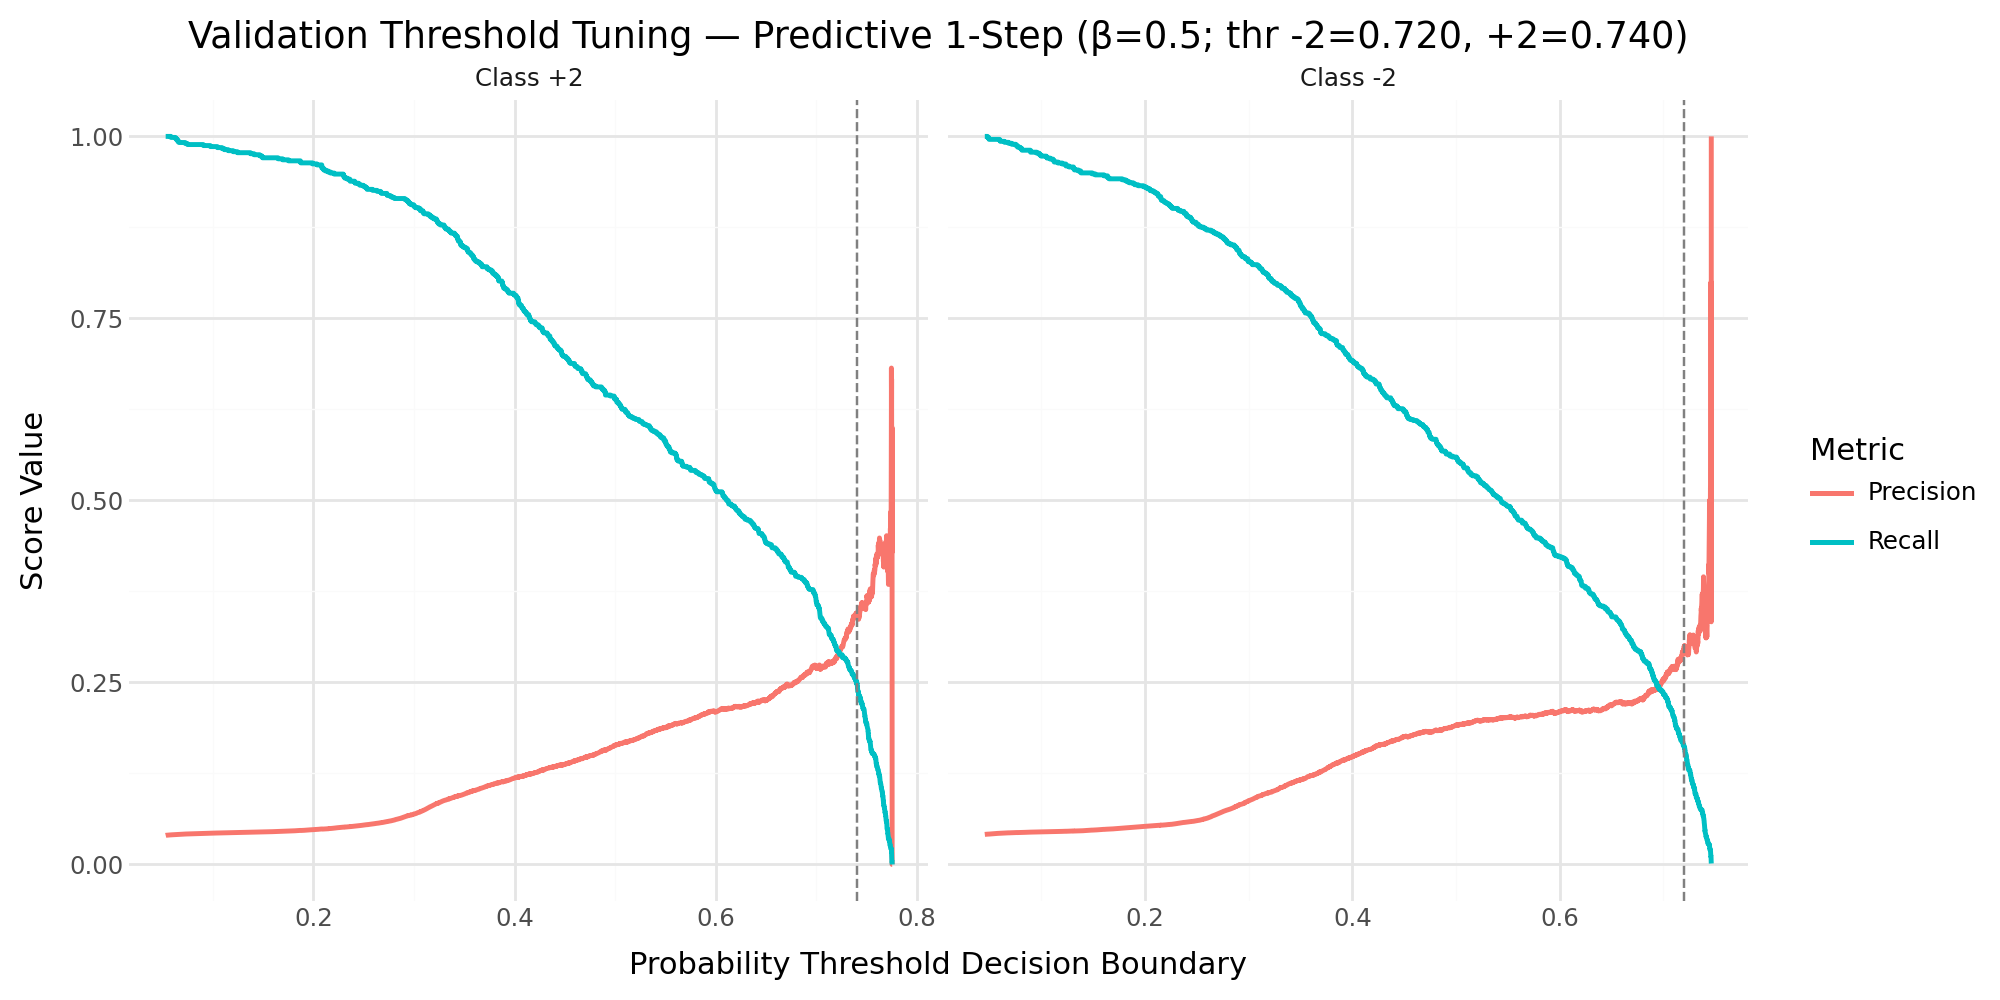

In [49]:
# --- Tune the predictive per-tail decision thresholds on VALIDATION (2024) --
y_val_f, probs_val_f = data_fwd['val']

THR_DOWN_F, THR_UP_F, fb_dn_f, fb_up_f = tune_thresholds(y_val_f, probs_val_f, beta=BETA)
argmax_fb_f = fbeta_score(y_val_f, np.array(CATS)[probs_val_f.argmax(1)],
                          beta=BETA, labels=CATS, average='macro', zero_division=0)
print(f'Validation tail thresholds (β={BETA}):  -2 → {THR_DOWN_F:.3f} (Fβ={fb_dn_f:.4f})  |  '
      f'+2 → {THR_UP_F:.3f} (Fβ={fb_up_f:.4f})   vs  arg-max-prob macro-Fβ = {argmax_fb_f:.4f}')

# Precision/Recall vs threshold on VALIDATION, with each tail's selected boundary marked.
pr_long_f = pr_threshold_df(y_val_f, probs_val_f)
thr_lines_f = pd.DataFrame({'Class': ['Class -2', 'Class +2'], 'thr': [THR_DOWN_F, THR_UP_F]})
(
    ggplot(pr_long_f, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(aes(xintercept='thr'), data=thr_lines_f, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step (β={BETA}; '
              f'thr -2={THR_DOWN_F:.3f}, +2={THR_UP_F:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Predictive 1-step | train (2021-2023) | thr=(-2:0.720, +2:0.740) | accuracy=0.8091 | n=73,822 ---
              precision    recall  f1-score   support

          -2       0.20      0.11      0.14      5233
           0       0.86      0.93      0.89     63203
          +2       0.22      0.13      0.16      5386

    accuracy                           0.81     73822
   macro avg       0.43      0.39      0.40     73822
weighted avg       0.77      0.81      0.79     73822


--- Predictive 1-step | val (2024) | thr=(-2:0.720, +2:0.740) | accuracy=0.9009 | n=17,869 ---
              precision    recall  f1-score   support

          -2       0.30      0.16      0.21       738
           0       0.93      0.96      0.95     16416
          +2       0.34      0.25      0.29       715

    accuracy                           0.90     17869
   macro avg       0.53      0.46      0.48     17869
weighted avg       0.88      0.90      0.89     17869


--- Predictive 1-step | test (2025) | 

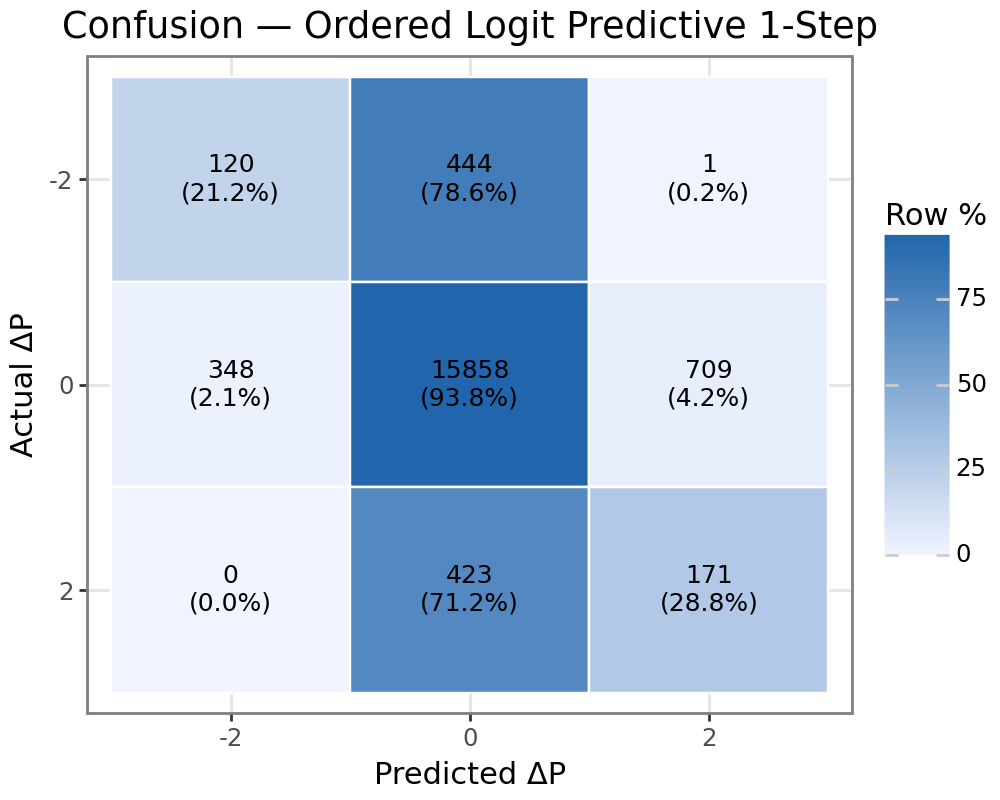

In [51]:
# --- Apply the validation-tuned thresholds: reports for all splits + TEST confusion matrix ---
report_all_splits(data_fwd, THR_DOWN_F, THR_UP_F, 'Predictive 1-step', split_labels=YEAR_LABEL)

y_test_f, probs_test_f = data_fwd['test']
confusion_tile(
    y_test_f, assign_classes(probs_test_f, THR_DOWN_F, THR_UP_F),
    title='Confusion — Ordered Logit Predictive 1-Step',
)

### Cross-`qcode` performance of the predictive model

The split-level reports above pool every tick-constrained curve group together. To check whether
the 1-step-ahead model is uniformly useful or only works on a subset, we break the **test (2025)**
tail performance out **by `qcode`**. The $+2$ and $-2$ classes are symmetric, so for each group
we report the **mean precision** and **mean recall** over the two tails (using the same fitted
model `res_fwd` and the same validation-tuned thresholds `THR_DOWN_F` / `THR_UP_F`). Groups are
ordered best → worst by $\tfrac12(\text{precision} + \text{recall})$; `tail_support` is the count
of actual $\pm2$ events, so thin bars on tiny support should be read with caution.

In [ ]:
# --- Per-qcode evaluation of the predictive model on TEST (2025) ----------
# Tail (+/-2) precision & recall, averaged over the two tail classes (they are symmetric),
# computed SEPARATELY for each qcode so we can see where the 1-step-ahead model
# generalises and where it degrades. Uses the SAME fitted model (res_fwd) and the SAME
# validation-tuned (THR_DOWN_F, THR_UP_F); we just re-materialise the test slice carrying
# qcode so every row can be grouped.
from sklearn.metrics import precision_recall_fscore_support

_pdf_bbg = (
    df_signals_tc_clean
    .filter(pl.col('date').dt.year().is_in(TEST_YEARS))
    .select(['delta_p_fwd', *TC_FEATURES, 'qcode'])
    .drop_nulls()
    .to_pandas()
)
_pdf_bbg['y']    = _pdf_bbg['delta_p_fwd'].astype(int)
_pdf_bbg['pred'] = assign_classes(
    np.asarray(res_fwd.predict(exog=_pdf_bbg[TC_FEATURES])), THR_DOWN_F, THR_UP_F
)

rows = []
for code, g in _pdf_bbg.groupby('qcode'):
    prec, rec, _, sup = precision_recall_fscore_support(
        g['y'], g['pred'], labels=[-2, 2], zero_division=0,
    )
    rows.append({
        'qcode': code,
        'Precision': float(prec.mean()),   # mean over the +2 and -2 classes
        'Recall': float(rec.mean()),
        'tail_support': int(sup.sum()),    # # of actual +/-2 observations
        'n': int(len(g)),
    })

bbg_metrics = (
    pd.DataFrame(rows)
    .assign(MeanPR=lambda d: (d['Precision'] + d['Recall']) / 2)
    .sort_values('MeanPR', ascending=False)
    .reset_index(drop=True)
)
print(bbg_metrics.to_string(index=False))

# Dodged precision/recall bars, qcode ordered best -> worst by mean(Precision, Recall).
_order   = bbg_metrics['qcode'].tolist()
_grand   = bbg_metrics[['Precision', 'Recall']].to_numpy().mean()
bbg_long = bbg_metrics.melt(
    id_vars=['qcode'], value_vars=['Precision', 'Recall'],
    var_name='Metric', value_name='Value',
)
bbg_long['qcode'] = pd.Categorical(bbg_long['qcode'], categories=_order, ordered=True)
(
    ggplot(bbg_long, aes(x='qcode', y='Value', fill='Metric'))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + geom_hline(yintercept=_grand, linetype='dashed', color='grey')
    + scale_y_continuous(limits=[0, 1])
    + labs(
        title=f'Predictive 1-Step — Tail (±2) Precision/Recall by qcode  '
              f'(test 2025, β={BETA})',
        subtitle='Mean over the +2 and -2 classes; qcode ordered best → worst by '
                 'mean(Precision, Recall). Dashed line = grand mean.',
        x='qcode', y='Score', fill='Metric',
    )
    + theme_minimal()
    + theme(figure_size=(11, 5), axis_text_x=element_text(rotation=45, hjust=1))
)

## Predictive Model + Outright Legs: Ordered Logit (1-Step-Ahead, 6 Features)

The same class-weighted ordered logit and out-of-sample protocol as the predictive model above,
but the feature set is augmented with the **outright legs' microstructure**. Alongside the
spread's own $OBI_t$ / $STV_t$ we add the normalised $OBI$ / $STV$ of the **buy** and **sell**
legs — resolved per `qcode` from `IS_CONVENTION_BUY_NEAR` (buy = near or far leg accordingly) and
joined on the matching `[date, bin_start_time]` — giving six features:

$$\mathbf{x}_t = [\,OBI_t,\ STV_t,\ OBI^{\text{buy}}_t,\ STV^{\text{buy}}_t,\ OBI^{\text{sell}}_t,\ STV^{\text{sell}}_t\,].$$

**Economic prior:** a quote/flow improvement on the **buy** leg should push the calendar-spread
price **up** ($+2$), and an improvement on the **sell** leg should push it **down** ($-2$).

Trained on 2021-2023, thresholds tuned on validation (2024), evaluated on test (2025) — reported
**pooled** and **per-`qcode`**. Bins where a leg signal is missing (leg outside its roll window)
are dropped by the fitter's `drop_nulls`, so this model is fit and scored on common leg-support.

In [ ]:
LEG_FEATURES = ['obi', 'stv', 'buy_obi', 'buy_stv', 'sell_obi', 'sell_stv']
res_fwd_leg, data_fwd_leg, _ = fit_ordered_logit(
    df_signals_tc_clean, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    target_col='delta_p_fwd', feature_cols=LEG_FEATURES,
    label='Predictive 1-step + legs', verbose=True,
)

In [ ]:
# --- Tune the leg-augmented per-tail decision thresholds on VALIDATION (2024) ---
y_val_fl, probs_val_fl = data_fwd_leg['val']

THR_DOWN_FL, THR_UP_FL, fb_dn_fl, fb_up_fl = tune_thresholds(y_val_fl, probs_val_fl, beta=BETA)
argmax_fb_fl = fbeta_score(y_val_fl, np.array(CATS)[probs_val_fl.argmax(1)],
                           beta=BETA, labels=CATS, average='macro', zero_division=0)
print(f'Validation tail thresholds (β={BETA}):  -2 → {THR_DOWN_FL:.3f} (Fβ={fb_dn_fl:.4f})  |  '
      f'+2 → {THR_UP_FL:.3f} (Fβ={fb_up_fl:.4f})   vs  arg-max-prob macro-Fβ = {argmax_fb_fl:.4f}')

# Precision/Recall vs threshold on VALIDATION, with each tail's selected boundary marked.
pr_long_fl = pr_threshold_df(y_val_fl, probs_val_fl)
thr_lines_fl = pd.DataFrame({'Class': ['Class -2', 'Class +2'], 'thr': [THR_DOWN_FL, THR_UP_FL]})
(
    ggplot(pr_long_fl, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(aes(xintercept='thr'), data=thr_lines_fl, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step + Legs (β={BETA}; '
              f'thr -2={THR_DOWN_FL:.3f}, +2={THR_UP_FL:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)

In [ ]:
# --- Pooled evaluation: reports for all splits + TEST confusion matrix ------
report_all_splits(data_fwd_leg, THR_DOWN_FL, THR_UP_FL, 'Predictive 1-step + legs',
                  split_labels=YEAR_LABEL)

y_test_fl, probs_test_fl = data_fwd_leg['test']
confusion_tile(
    y_test_fl, assign_classes(probs_test_fl, THR_DOWN_FL, THR_UP_FL),
    title=f'Test (2025) Confusion — Ordered Logit Predictive 1-Step + Legs  '
          f'(thr -2={THR_DOWN_FL:.3f}, +2={THR_UP_FL:.3f})',
)

### Cross-`qcode` comparison: does adding the legs help?

To isolate the **incremental** value of the outright-leg features, both models are scored on the
**same test (2025) rows** — those where every leg feature is present, so the 6-feature model is
defined (`common leg-support`). For each `qcode` we report the tail ($\pm2$) **mean precision /
recall**, then compare the base 3-feature predictive model against the leg-augmented 6-feature
one. A positive `Delta` means the legs improve that curve group; this surfaces where the
buy/sell-leg microstructure carries genuine predictive signal versus where it adds nothing.

In [ ]:
# --- Per-qcode: base (3f) vs leg-augmented (6f) on COMMON leg-support (test 2025) ---
# Both models are scored on the SAME rows (every leg feature present) so the comparison
# reflects only the added features, not a change in the evaluated sample. Each model uses its
# OWN validation-tuned per-tail thresholds. Tail (+/-2) precision/recall are averaged over the
# two symmetric classes within each qcode.
ALL_FEATS = sorted(set(TC_FEATURES) | set(LEG_FEATURES))   # union: obi, noi, stv, buy_*, sell_*

_cmp = (
    df_signals_tc_clean
    .filter(pl.col('date').dt.year().is_in(TEST_YEARS))
    .select(['delta_p_fwd', *ALL_FEATS, 'qcode'])
    .drop_nulls()
    .to_pandas()
)
_cmp['y'] = _cmp['delta_p_fwd'].astype(int)
_cmp['pred_base'] = assign_classes(
    np.asarray(res_fwd.predict(exog=_cmp[TC_FEATURES])), THR_DOWN_F, THR_UP_F)
_cmp['pred_leg']  = assign_classes(
    np.asarray(res_fwd_leg.predict(exog=_cmp[LEG_FEATURES])), THR_DOWN_FL, THR_UP_FL)


def _tail_pr(g, pred_col):
    """Mean precision/recall over the two tail classes (+/-2) for one qcode group."""
    prec, rec, _, sup = precision_recall_fscore_support(
        g['y'], g[pred_col], labels=[-2, 2], zero_division=0)
    return {'Precision': float(prec.mean()), 'Recall': float(rec.mean()),
            'MeanPR': float((prec.mean() + rec.mean()) / 2), 'tail_support': int(sup.sum())}

rows = []
for code, g in _cmp.groupby('qcode'):
    for model, pc in (('Base (3f)', 'pred_base'), ('+Legs (6f)', 'pred_leg')):
        rows.append({'qcode': code, 'Model': model, **_tail_pr(g, pc), 'n': int(len(g))})
cmp_metrics = pd.DataFrame(rows)

# Wide MeanPR table with the base -> legs delta, ordered by the leg model.
wide = (
    cmp_metrics.pivot_table(index='qcode', columns='Model', values='Precision')
    .assign(Delta=lambda d: d['+Legs (6f)'] - d['Base (3f)'])
    .sort_values('+Legs (6f)', ascending=False)
)
print(wide.to_string(float_format=lambda x: f'{x:.3f}'))

# Dodged bars: base vs legs per qcode (ordered best -> worst by the leg model's MeanPR).
_order = wide.index.tolist()
cmp_metrics['qcode'] = pd.Categorical(cmp_metrics['qcode'], categories=_order, ordered=True)
cmp_metrics['Model'] = pd.Categorical(cmp_metrics['Model'], categories=['Base (3f)', '+Legs (6f)'])
(
    ggplot(cmp_metrics, aes(x='qcode', y='Precision', fill='Model'))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + scale_y_continuous(limits=[0, 1])
    + labs(
        title=f'Per-qcode Tail (±2) Precision — Base vs +Legs  '
              f'(test 2025, β={BETA}, common leg-support, n={len(_cmp):,})',
        subtitle='Mean over the +2 and -2 classes; both models scored on identical rows. '
                 'qcode ordered best → worst by the +Legs score.',
        x='qcode', y='Mean(Precision, Recall)', fill='Model',
    )
    + theme_minimal()
    + theme(figure_size=(11, 5), axis_text_x=element_text(rotation=45, hjust=1))
)